# Change in Current Asset Ratio (CCH) Signal Analysis

## Summary
This notebook evaluates the **Change in Cash Holdings (CCH)** signal, adapted from the academic literature.

**Signal definition:**
$$CCH_t = \frac{CurrentAssets_t}{Assets_t} - \frac{CurrentAssets_{t-1}}{Assets_{t-1}}$$

Computed from **Sharadar SF1 ARQ** at `datekey` (SEC filing date) — no look-ahead bias.  
Market equity (ME) from **Sharadar DAILY** `marketcap`. Prices/returns from **Sharadar SEP** (split-adjusted equity prices).

**Hypothesis:** Firms that increase their liquidity ratio outperform in subsequent months.

**Date coverage:**
- CCH signal: **1998** onwards (SEP prices from 1998 + SF1 filings from 1993)
- VW evaluation: **1999** onwards (Sharadar DAILY marketcap starts 1999-01)
- Equal-weighted evaluation uses all months where CCH is available (1998+)

**Analysis structure:**
1. Signal overview — distribution, coverage
2. Quintile portfolio sorts — equal-weighted and value-weighted returns
3. Risk-adjusted performance — CAPM, FF3/FF4 alphas; rolling 60-month alpha; annualized return and Sharpe bar charts
4. Size-controlled double sort — Low ME vs High ME panels
5. Fama-MacBeth cross-sectional regressions — 4 models (raw ER / FF3-adj ER, univariate / with controls)

**Data:** `algotrading/prod/signals/cch.parquet` built by `scripts/signals/monthly/compute_cch_signal.py`

In [65]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from io import BytesIO
from dotenv import load_dotenv

load_dotenv()
sys.path.insert(0, os.path.join(os.getcwd(), '../../..'))

import boto3
from algotrading.infra.s3_client import S3Client

s3 = S3Client()
BUCKET = os.environ['S3_BUCKET']

## 0. Load Data

In [66]:
# Load CCH signal panel (built by scripts/signals/monthly/compute_cch_signal.py)
s3_client = boto3.client('s3', region_name=os.environ.get('AWS_REGION', 'us-east-1'))
obj = s3_client.get_object(Bucket=BUCKET, Key='algotrading/prod/signals/cch.parquet')
df = pd.read_parquet(BytesIO(obj['Body'].read()))
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['ticker', 'date']).reset_index(drop=True)
print(f"Raw panel: {len(df):,} rows | {df['ticker'].nunique():,} tickers | {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Columns: {list(df.columns)}")

# Universe filter: domestic common stocks, USD, from Sharadar TICKERS
tickers_dim = s3.read_sharadar_tickers()
universe = tickers_dim[
    tickers_dim['category'].isin(['Domestic Common Stock', 'Domestic Common Stock Primary Class']) &
    (tickers_dim['currency'] == 'USD')
]['ticker'].unique()

df = df[df['ticker'].isin(universe)].copy()
print(f"\nAfter universe filter (domestic common stocks): {len(df):,} rows | {df['ticker'].nunique():,} tickers")
df.head()

Raw panel: 2,209,910 rows | 21,731 tickers | 1997-12-31 → 2026-04-30
Columns: ['ticker', 'close', 'date', 'ret', 'ME', 'CCH']

After universe filter (domestic common stocks): 1,796,302 rows | 15,552 tickers


,ticker,close,date,ret,ME,CCH
0,A,42.19,1999-11-30,NaN,1.877450e+10,NaN
1,A,77.31,1999-12-31,0.832425,3.440290e+10,NaN
2,A,66.19,2000-01-31,-0.143837,2.991790e+10,0.005137
3,A,103.90,2000-02-29,0.569724,4.696280e+10,0.005137
4,A,104.00,2000-03-31,0.000962,4.700800e+10,0.051109


In [67]:
# Load Fama-French 3-factor monthly data from S3
ff3 = s3.read_ff_factors().set_index('date')
print(ff3.tail())

            mkt_rf     smb     hml      rf     umd
date                                              
2025-10-31  0.0196 -0.0055 -0.0310  0.0037  0.0027
2025-11-30 -0.0013  0.0038  0.0376  0.0030 -0.0180
2025-12-31 -0.0036 -0.0106  0.0242  0.0034 -0.0241
2026-01-31  0.0102  0.0220  0.0372  0.0030  0.0496
2026-02-28 -0.0117  0.0014  0.0283  0.0028  0.0133


In [68]:
# Merge FF factors onto panel
df = df.merge(ff3.reset_index(), on='date', how='left')
df['ret_excess'] = df['ret'] - df['rf']

# Winsorize returns cross-sectionally each month at 1st/99th percentile
def winsorize_cross_section(s):
    lo, hi = s.quantile(0.01), s.quantile(0.99)
    return s.clip(lo, hi)

df['ret']        = df.groupby('date')['ret'].transform(winsorize_cross_section)
df['ret_excess'] = df.groupby('date')['ret_excess'].transform(winsorize_cross_section)

df['ret_next']        = df.groupby('ticker')['ret'].shift(-1)
df['ret_next_excess'] = df.groupby('ticker')['ret_excess'].shift(-1)

# Working sample: require CCH and next month return
sample = df.dropna(subset=['CCH', 'ret_next']).copy()
print(f"Working sample: {len(sample):,} ticker-months | {sample['ticker'].nunique():,} tickers")
print(f"ret range after winsorization: [{df['ret'].min():.3f}, {df['ret'].max():.3f}]")

Working sample: 1,364,248 ticker-months | 12,660 tickers
ret range after winsorization: [-0.751, 2.199]


## 1. Signal Overview

In [69]:
print(sample['CCH'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))

count    1.364248e+06
mean    -2.464486e-03
std      6.169887e+00
min     -2.880996e+03
1%      -2.197258e-01
5%      -7.815070e-02
25%     -1.488895e-02
50%      0.000000e+00
75%      1.349132e-02
95%      7.050968e-02
99%      2.142972e-01
max      2.880917e+03
Name: CCH, dtype: float64


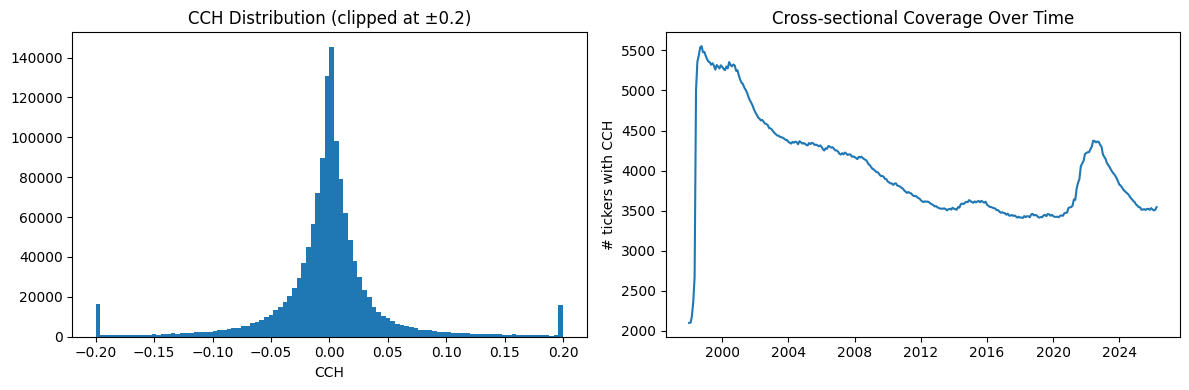

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution (winsorized for readability)
cch_clipped = sample['CCH'].clip(-0.2, 0.2)
axes[0].hist(cch_clipped, bins=100, edgecolor='none')
axes[0].set_title('CCH Distribution (clipped at ±0.2)')
axes[0].set_xlabel('CCH')

# Coverage over time
coverage = sample.groupby('date')['CCH'].count()
axes[1].plot(coverage.index, coverage.values)
axes[1].set_title('Cross-sectional Coverage Over Time')
axes[1].set_ylabel('# tickers with CCH')

plt.tight_layout()
plt.show()

## 2. Quintile Portfolio Sorts

In [71]:
# Assign quintiles cross-sectionally each month
def assign_quintiles(group):
    try:
        return pd.qcut(group['CCH'], 5, labels=False, duplicates='drop') + 1
    except ValueError:
        return np.nan

sample['Q'] = sample.groupby('date', group_keys=False).apply(assign_quintiles)
sample = sample.dropna(subset=['Q'])
sample['Q'] = sample['Q'].astype(int)
print(sample['Q'].value_counts().sort_index())

Q
1    272990
2    273001
3    272622
4    272719
5    272916
Name: count, dtype: int64


In [72]:
# Equal-weighted monthly returns per quintile
ew = sample.groupby(['date', 'Q'])['ret_next_excess'].mean().unstack('Q')
ew['5-1'] = ew[5] - ew[1]

# Value-weighted monthly returns (where ME available — naturally starts 1999)
def vw_return(group):
    valid = group.dropna(subset=['ME'])
    if valid.empty:
        return np.nan
    return np.average(valid['ret_next_excess'], weights=valid['ME'])

vw = sample.groupby(['date', 'Q']).apply(vw_return).unstack('Q')
vw['5-1'] = vw[5] - vw[1]

ew_valid = ew['5-1'].dropna()
vw_valid = vw['5-1'].dropna()
print(f"EW  5-1: {len(ew_valid)} months  |  {ew_valid.index.min().date()} → {ew_valid.index.max().date()}")
print(f"VW  5-1: {len(vw_valid)} months  |  {vw_valid.index.min().date()} → {vw_valid.index.max().date()}")
print(f"(VW starts when Sharadar DAILY marketcap is available)")

EW  5-1: 338 months  |  1997-12-31 → 2026-01-31
VW  5-1: 326 months  |  1998-12-31 → 2026-01-31
(VW starts when Sharadar DAILY marketcap is available)


In [73]:
# Performance table helper
def perf_table(port_matrix, ff3, label='EW'):
    ff = ff3.reindex(port_matrix.index)
    has_umd = 'umd' in ff.columns and ff['umd'].notna().any()
    results = []
    for col in [1, 2, 3, 4, 5, '5-1']:
        y = port_matrix[col].dropna()
        ff_aligned = ff.reindex(y.index).dropna()
        y = y.reindex(ff_aligned.index)
        n = len(y)
        mean = y.mean()
        std = y.std()
        sharpe = mean / std * np.sqrt(12)
        t_mean = mean / (std / np.sqrt(n))

        # CAPM
        X1 = sm.add_constant(ff_aligned['mkt_rf'])
        m1 = sm.OLS(y, X1).fit()

        # FF3
        X3 = sm.add_constant(ff_aligned[['mkt_rf', 'smb', 'hml']])
        m3 = sm.OLS(y, X3).fit()

        row = {
            'Portfolio': col,
            'Mean (%)': round(mean * 100, 3),
            't-Mean': round(t_mean, 2),
            'Sharpe': round(sharpe, 2),
            'α-CAPM (%)': round(m1.params['const'] * 100, 3),
            't-CAPM': round(m1.tvalues['const'], 2),
            'β-MKT (CAPM)': round(m1.params['mkt_rf'], 3),
            'α-FF3 (%)': round(m3.params['const'] * 100, 3),
            't-FF3': round(m3.tvalues['const'], 2),
            'β-MKT': round(m3.params['mkt_rf'], 3),
            'β-SMB': round(m3.params['smb'], 3),
            'β-HML': round(m3.params['hml'], 3),
        }

        if has_umd:
            ff_umd = ff_aligned.dropna(subset=['umd'])
            y_umd = y.reindex(ff_umd.index)
            X4 = sm.add_constant(ff_umd[['mkt_rf', 'smb', 'hml', 'umd']])
            m4 = sm.OLS(y_umd, X4).fit()
            row['α-FF4 (%)'] = round(m4.params['const'] * 100, 3)
            row['t-FF4'] = round(m4.tvalues['const'], 2)
            row['β-UMD'] = round(m4.params['umd'], 3)

        results.append(row)
    return pd.DataFrame(results).set_index('Portfolio')

print('=== Equal-Weighted ===')
display(perf_table(ew, ff3, 'EW'))
print('\n=== Value-Weighted ===')
display(perf_table(vw, ff3, 'VW'))

=== Equal-Weighted ===


,Mean (%),t-Mean,Sharpe,α-CAPM (%),t-CAPM,β-MKT (CAPM),α-FF3 (%),t-FF3,β-MKT,β-SMB,β-HML,α-FF4 (%),t-FF4,β-UMD
Portfolio,,,,,,,,,,,,,,
1,-0.184,-0.44,-0.08,-0.359,-0.86,0.255,-0.330,-0.79,0.228,0.085,-0.177,-0.302,-0.71,-0.045
2,0.444,1.25,0.24,0.297,0.83,0.215,0.319,0.89,0.196,0.058,-0.134,0.358,0.99,-0.063
3,0.438,1.35,0.25,0.284,0.88,0.224,0.302,0.93,0.206,0.063,-0.099,0.350,1.07,-0.077
4,0.777,2.38,0.45,0.657,2.01,0.174,0.673,2.05,0.155,0.074,-0.081,0.723,2.18,-0.080
5,0.478,1.26,0.24,0.334,0.87,0.210,0.358,0.94,0.184,0.097,-0.128,0.421,1.09,-0.102
5-1,0.662,6.26,1.18,0.694,6.51,-0.045,0.688,6.45,-0.045,0.013,0.049,0.723,6.78,-0.057



=== Value-Weighted ===


,Mean (%),t-Mean,Sharpe,α-CAPM (%),t-CAPM,β-MKT (CAPM),α-FF3 (%),t-FF3,β-MKT,β-SMB,β-HML,α-FF4 (%),t-FF4,β-UMD
Portfolio,,,,,,,,,,,,,,
1,0.419,1.38,0.27,0.387,1.26,0.047,0.415,1.36,0.023,0.079,-0.206,0.411,1.34,0.006
2,0.474,1.84,0.35,0.447,1.72,0.039,0.468,1.80,0.046,-0.067,-0.136,0.466,1.78,0.003
3,0.370,1.49,0.29,0.342,1.36,0.043,0.359,1.43,0.043,-0.029,-0.119,0.384,1.52,-0.044
4,0.548,2.27,0.44,0.545,2.23,0.005,0.558,2.28,0.005,-0.024,-0.094,0.588,2.38,-0.052
5,0.634,2.22,0.43,0.623,2.15,0.017,0.644,2.23,0.008,0.009,-0.151,0.688,2.36,-0.075
5-1,0.215,1.57,0.30,0.236,1.70,-0.031,0.229,1.66,-0.015,-0.069,0.055,0.276,2.01,-0.081


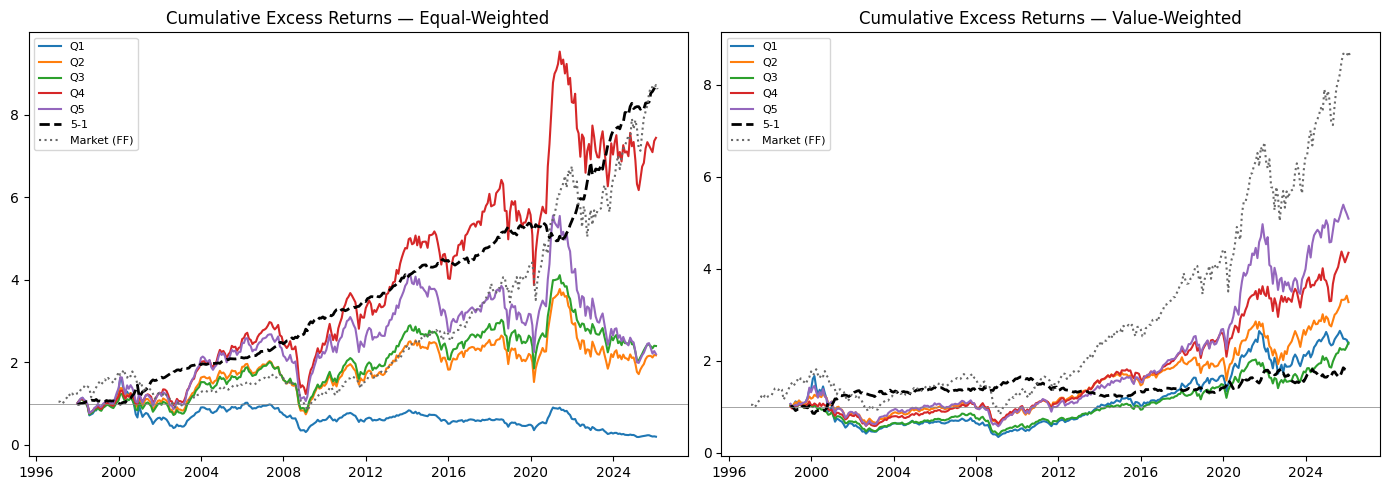

In [74]:
# Cumulative excess return plot with market benchmark
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mkt_cum = (1 + ff3['mkt_rf'].dropna()).cumprod()

for port_matrix, title, ax in [(ew, 'Equal-Weighted', axes[0]), (vw, 'Value-Weighted', axes[1])]:
    for col in [1, 2, 3, 4, 5]:
        cum = (1 + port_matrix[col].dropna()).cumprod()
        ax.plot(cum.index, cum.values, label=f'Q{col}')
    spread = (1 + port_matrix['5-1'].dropna()).cumprod()
    ax.plot(spread.index, spread.values, label='5-1', linestyle='--', color='black', linewidth=2)
    ax.plot(mkt_cum.index, mkt_cum.values, label='Market (FF)', linestyle=':', color='dimgray', linewidth=1.5)
    ax.set_title(f'Cumulative Excess Returns — {title}')
    ax.legend(fontsize=8)
    ax.axhline(1, color='grey', linewidth=0.5)

plt.tight_layout()
plt.show()

## 3. Portfolio Visualization

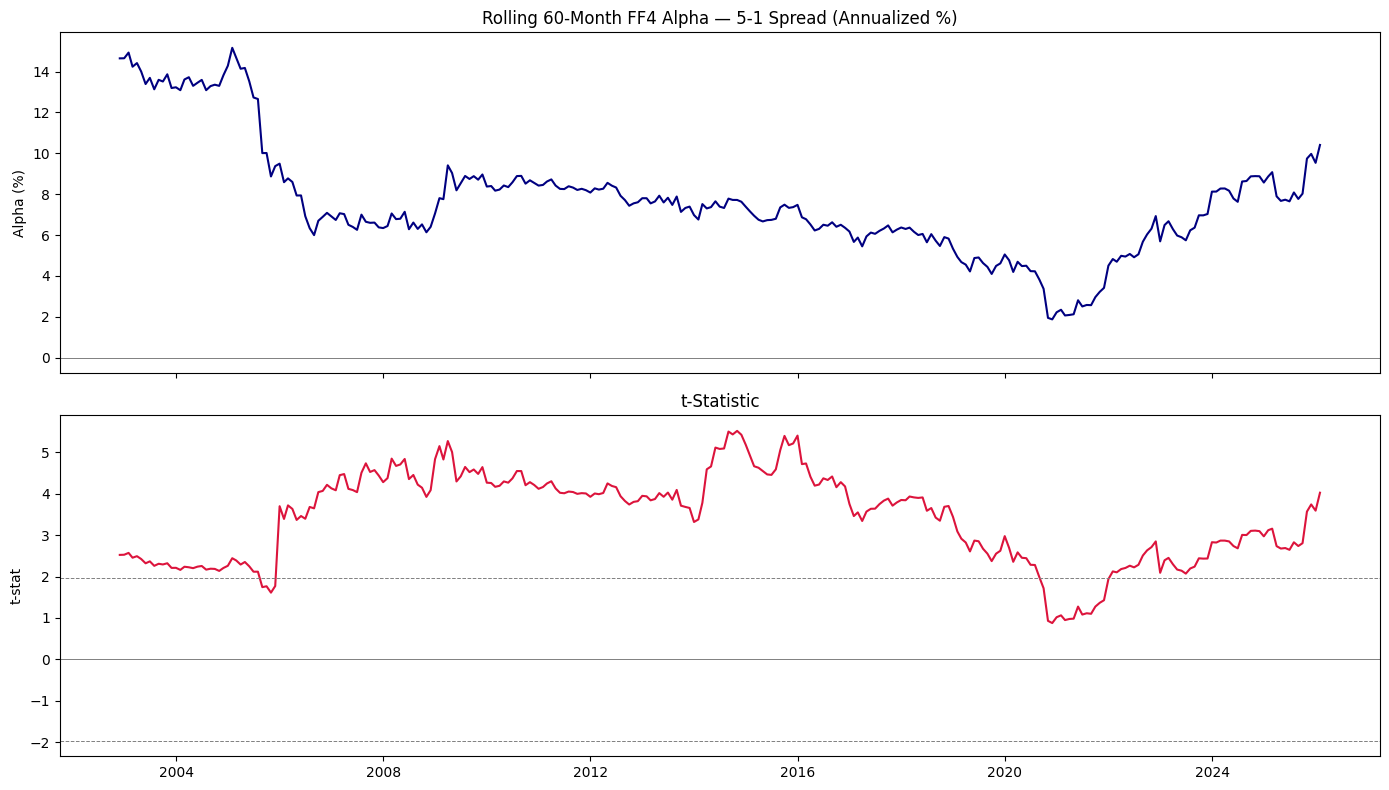

In [75]:
# Rolling 60-month alpha for the 5-1 spread (FF3, or FF4 if UMD available)
def rolling_alpha(series, ff3, window=60):
    has_umd = 'umd' in ff3.columns and ff3['umd'].notna().any()
    factor_cols = ['mkt_rf', 'smb', 'hml', 'umd'] if has_umd else ['mkt_rf', 'smb', 'hml']
    label = 'FF4' if has_umd else 'FF3'

    df = series.rename('y').to_frame().join(ff3[factor_cols], how='inner').dropna()
    alphas, tstats, dates = [], [], []
    for end in range(window - 1, len(df)):
        start = end - window + 1
        chunk = df.iloc[start:end + 1]
        y = chunk['y']
        X = sm.add_constant(chunk[factor_cols])
        res = sm.OLS(y, X).fit()
        alphas.append(res.params['const'] * 12)
        tstats.append(res.tvalues['const'])
        dates.append(chunk.index[-1])
    return pd.DataFrame({'alpha': alphas, 't_alpha': tstats}, index=dates), label

roll, factor_label = rolling_alpha(ew['5-1'].dropna(), ff3)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(roll.index, roll['alpha'] * 100, color='navy')
axes[0].axhline(0, color='grey', linewidth=0.7)
axes[0].set_title(f'Rolling 60-Month {factor_label} Alpha — 5-1 Spread (Annualized %)')
axes[0].set_ylabel('Alpha (%)')
axes[1].plot(roll.index, roll['t_alpha'], color='crimson')
axes[1].axhline(0, color='grey', linewidth=0.7)
axes[1].axhline(1.96, color='grey', linewidth=0.7, linestyle='--')
axes[1].axhline(-1.96, color='grey', linewidth=0.7, linestyle='--')
axes[1].set_title('t-Statistic')
axes[1].set_ylabel('t-stat')
plt.tight_layout()
plt.show()

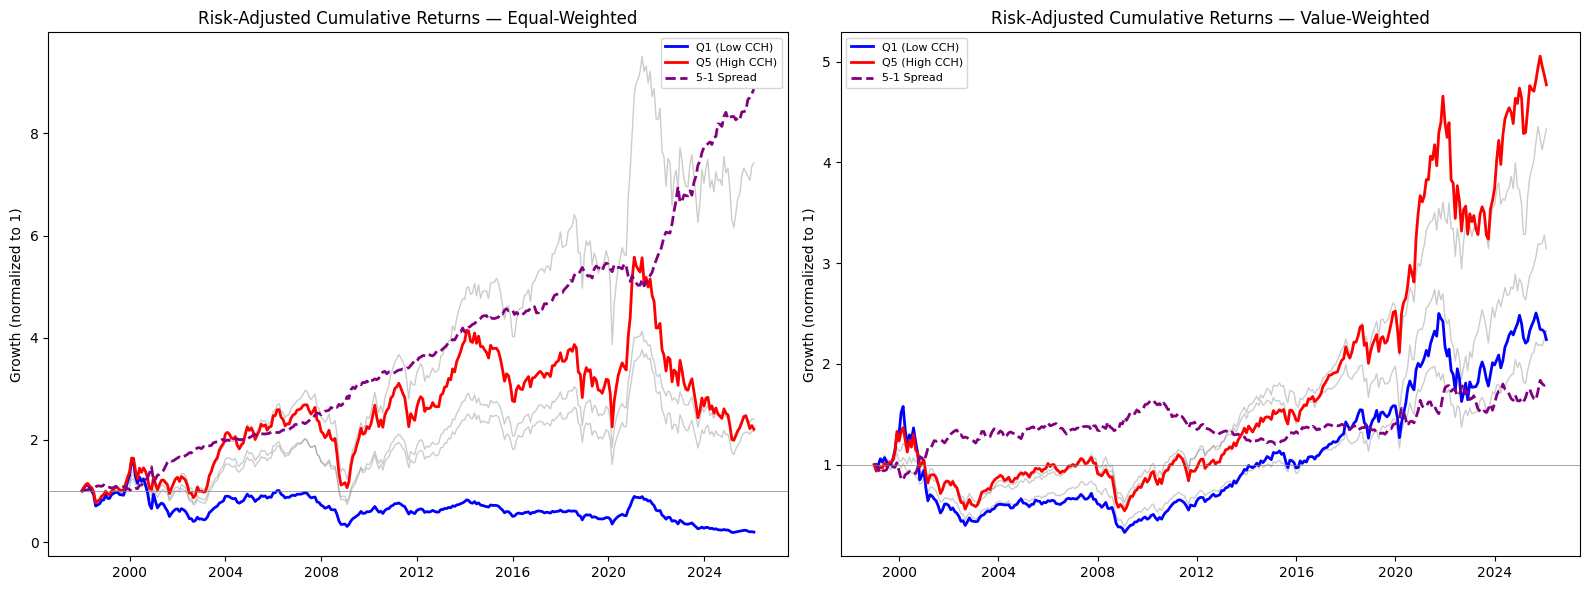

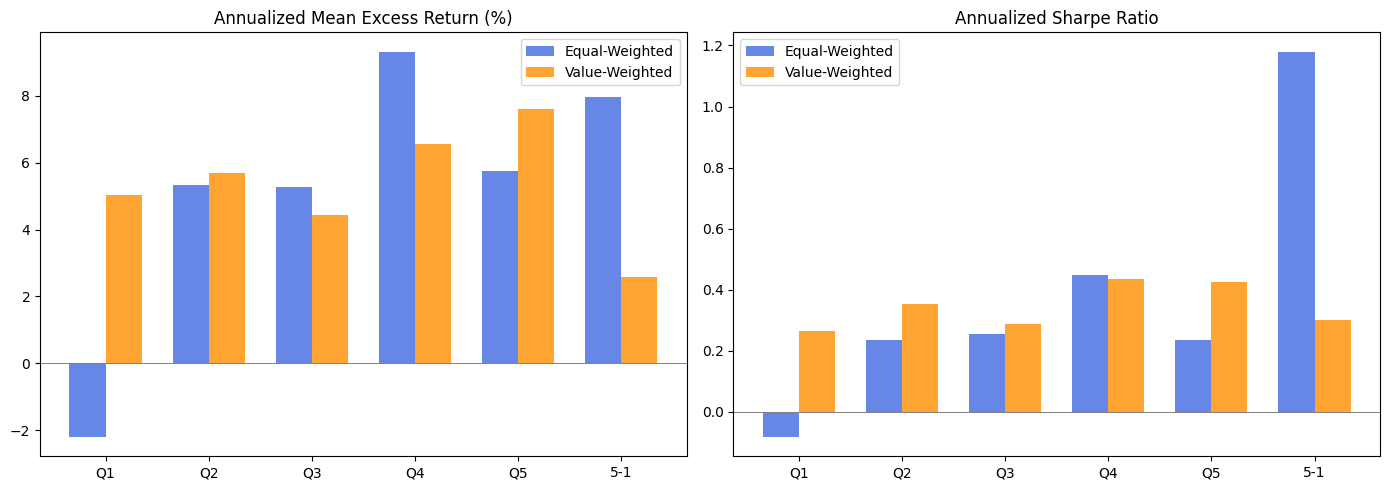

In [76]:
# Risk-adjusted cumulative returns (vol-scaled, normalized to start at 1) + annualized bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for port_matrix, title, ax in [(ew, 'Equal-Weighted', axes[0]), (vw, 'Value-Weighted', axes[1])]:
    cols = [1, 2, 3, 4, 5, '5-1']
    cum = (1 + port_matrix[cols].dropna()).cumprod()
    risk_adj = cum / port_matrix[cols].std()
    risk_adj = risk_adj / risk_adj.iloc[0]  # normalize to start at 1
    for p in [2, 3, 4]:
        ax.plot(risk_adj.index, risk_adj[p], color='grey', alpha=0.4, linewidth=1)
    ax.plot(risk_adj.index, risk_adj[1], label='Q1 (Low CCH)', color='blue', linewidth=2)
    ax.plot(risk_adj.index, risk_adj[5], label='Q5 (High CCH)', color='red', linewidth=2)
    ax.plot(risk_adj.index, risk_adj['5-1'], label='5-1 Spread', color='purple', linestyle='--', linewidth=2)
    ax.axhline(1, color='grey', linewidth=0.5)
    ax.set_title(f'Risk-Adjusted Cumulative Returns — {title}')
    ax.set_ylabel('Growth (normalized to 1)')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', '5-1']
cols = [1, 2, 3, 4, 5, '5-1']
for port_matrix, title, color in [(ew, 'Equal-Weighted', 'royalblue'), (vw, 'Value-Weighted', 'darkorange')]:
    ann_ret = [port_matrix[c].dropna().mean() * 12 * 100 for c in cols]
    sharpes  = [port_matrix[c].dropna().mean() / port_matrix[c].dropna().std() * np.sqrt(12) for c in cols]
    x = np.arange(len(labels))
    width, offset = 0.35, (-0.175 if color == 'royalblue' else 0.175)
    axes[0].bar(x + offset, ann_ret, width, label=title, color=color, alpha=0.8)
    axes[1].bar(x + offset, sharpes,  width, label=title, color=color, alpha=0.8)
for ax, title in zip(axes, ['Annualized Mean Excess Return (%)', 'Annualized Sharpe Ratio']):
    ax.set_title(title)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.axhline(0, color='grey', linewidth=0.7)
    ax.legend()
plt.tight_layout()
plt.show()

## 3b. Size-Controlled Portfolio Analysis (Double Sort)

Split stocks into **Low ME / High ME** (below / above monthly median market cap),
then assign CCH quintiles within each size group.
Tests whether CCH signal holds across the size spectrum.


==================== Low ME ====================


,Mean (%),t-Mean,Sharpe,α-CAPM (%),t-CAPM,β-MKT (CAPM),α-FF3 (%),t-FF3,β-MKT,β-SMB,β-HML,α-FF4 (%),t-FF4,β-UMD
Portfolio,,,,,,,,,,,,,,
1,-0.112,-0.24,-0.05,-0.324,-0.70,0.318,-0.290,-0.63,0.298,0.047,-0.248,-0.286,-0.61,-0.006
2,0.465,1.11,0.21,0.280,0.67,0.278,0.306,0.73,0.270,-0.003,-0.187,0.334,0.79,-0.048
3,0.586,1.60,0.31,0.381,1.05,0.306,0.403,1.11,0.302,-0.011,-0.154,0.420,1.15,-0.030
4,0.893,2.37,0.45,0.743,1.97,0.225,0.753,1.99,0.209,0.065,-0.079,0.780,2.04,-0.046
5,0.554,1.29,0.25,0.363,0.85,0.286,0.393,0.92,0.261,0.080,-0.224,0.441,1.02,-0.081
5-1,0.666,4.88,0.94,0.687,4.98,-0.032,0.683,4.94,-0.037,0.032,0.024,0.727,5.26,-0.075



==================== High ME ====================


,Mean (%),t-Mean,Sharpe,α-CAPM (%),t-CAPM,β-MKT (CAPM),α-FF3 (%),t-FF3,β-MKT,β-SMB,β-HML,α-FF4 (%),t-FF4,β-UMD
Portfolio,,,,,,,,,,,,,,
1,0.442,1.48,0.28,0.399,1.32,0.064,0.429,1.43,0.042,0.061,-0.224,0.425,1.40,0.008
2,0.420,1.67,0.32,0.409,1.61,0.017,0.426,1.67,0.021,-0.049,-0.113,0.430,1.67,-0.008
3,0.412,1.64,0.31,0.387,1.52,0.037,0.405,1.60,0.037,-0.030,-0.124,0.433,1.69,-0.048
4,0.520,2.15,0.41,0.520,2.12,-0.000,0.532,2.17,-0.001,-0.016,-0.085,0.562,2.27,-0.051
5,0.650,2.29,0.44,0.640,2.23,0.015,0.661,2.31,0.006,0.010,-0.150,0.697,2.42,-0.062
5-1,0.208,1.56,0.30,0.241,1.80,-0.049,0.231,1.73,-0.036,-0.051,0.074,0.272,2.04,-0.070


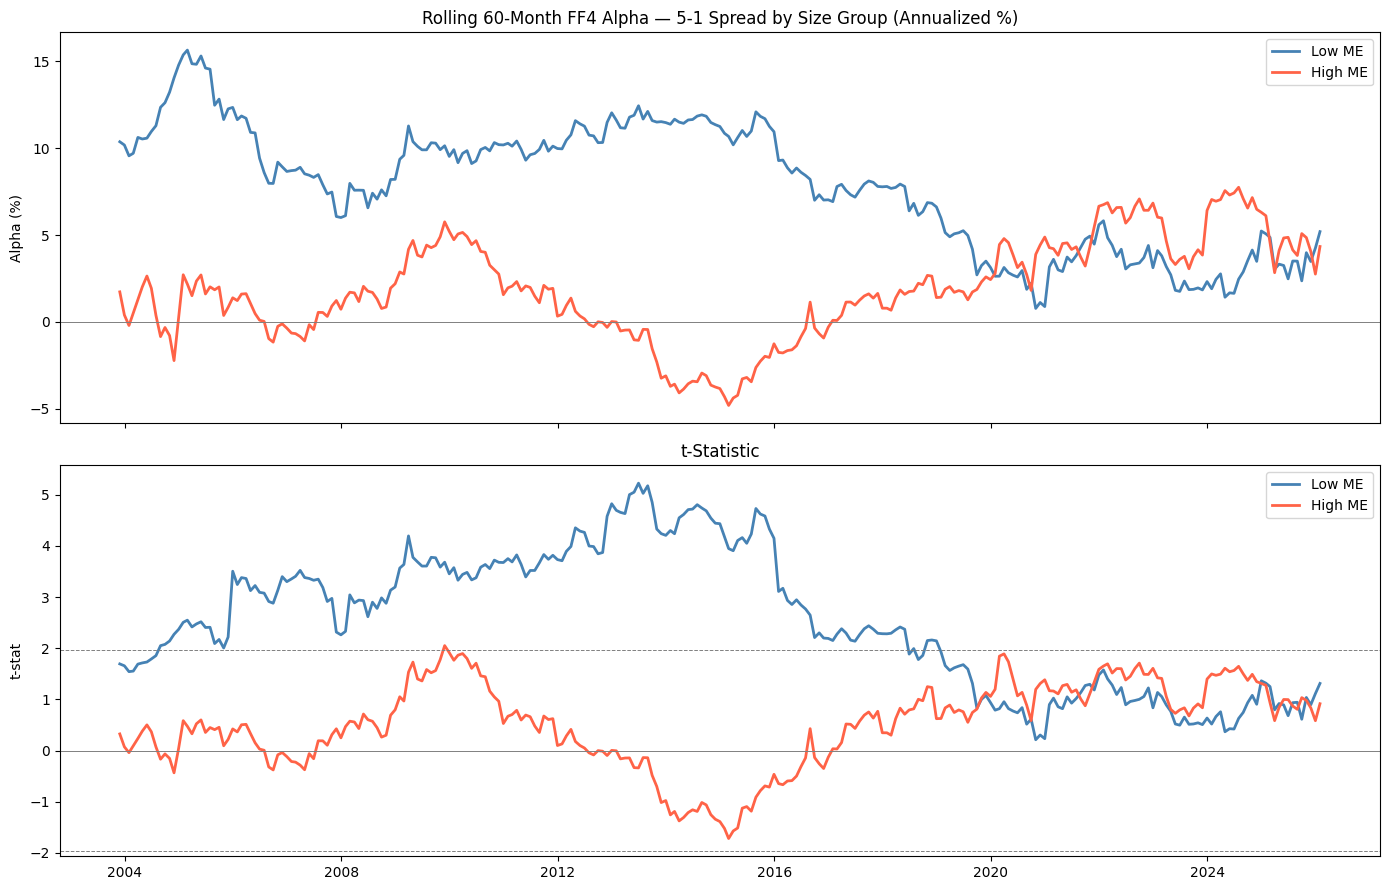

In [77]:
# Double sort: size group x CCH quintile, VW returns within each cell
sample_port = sample.dropna(subset=['CCH', 'ret_next_excess', 'ME']).copy()

# Size split: below/above monthly median ME
sample_port['size_median'] = sample_port.groupby('date')['ME'].transform('median')
sample_port['size_group'] = np.where(sample_port['ME'] < sample_port['size_median'], 'Low ME', 'High ME')

# CCH quintiles within (date, size_group)
def assign_q(group):
    try:
        return pd.qcut(group['CCH'], 5, labels=False, duplicates='drop') + 1
    except ValueError:
        return np.nan

sample_port['Q_me'] = (
    sample_port.groupby(['date', 'size_group'], group_keys=False)
               .apply(assign_q)
)
sample_port = sample_port.dropna(subset=['Q_me'])
sample_port['Q_me'] = sample_port['Q_me'].astype(int)

# VW return per (date, size_group, quintile)
def vw_ret(group):
    return np.average(group['ret_next_excess'], weights=group['ME'])

port_me = (
    sample_port.groupby(['date', 'size_group', 'Q_me'])
               .apply(vw_ret)
               .reset_index(name='ret')
)

# --- Performance table for each size group ---
has_umd = 'umd' in ff3.columns and ff3['umd'].notna().any()
factor_cols = ['mkt_rf', 'smb', 'hml', 'umd'] if has_umd else ['mkt_rf', 'smb', 'hml']

rolling_me = {}

for size in ['Low ME', 'High ME']:
    print(f"\n{'='*20} {size} {'='*20}")
    sub = port_me[port_me['size_group'] == size]
    mat = sub.pivot(index='date', columns='Q_me', values='ret')
    mat['5-1'] = mat[5] - mat[1]
    display(perf_table(mat, ff3, size))

    # Store for rolling alpha plot
    rolling_me[size] = mat

# --- Rolling alpha: Low ME vs High ME spread ---
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
factor_label = 'FF4' if has_umd else 'FF3'
colors = {'Low ME': 'steelblue', 'High ME': 'tomato'}

for size, mat in rolling_me.items():
    roll_size, _ = rolling_alpha(mat['5-1'].dropna(), ff3)
    axes[0].plot(roll_size.index, roll_size['alpha'] * 100,
                 label=size, color=colors[size], linewidth=2)
    axes[1].plot(roll_size.index, roll_size['t_alpha'],
                 label=size, color=colors[size], linewidth=2)

axes[0].axhline(0, color='grey', linewidth=0.7)
axes[0].set_title(f'Rolling 60-Month {factor_label} Alpha — 5-1 Spread by Size Group (Annualized %)')
axes[0].set_ylabel('Alpha (%)')
axes[0].legend()

axes[1].axhline(0, color='grey', linewidth=0.7)
axes[1].axhline(1.96,  color='grey', linewidth=0.7, linestyle='--')
axes[1].axhline(-1.96, color='grey', linewidth=0.7, linestyle='--')
axes[1].set_title('t-Statistic')
axes[1].set_ylabel('t-stat')
axes[1].legend()

plt.tight_layout()
plt.show()

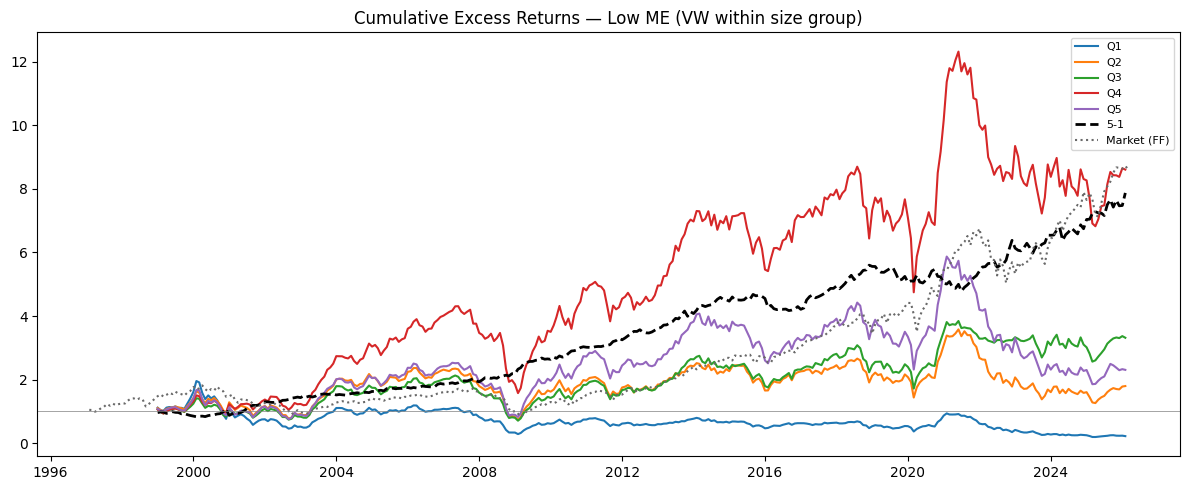

In [78]:
# Cumulative excess returns — Low ME quintiles vs market
fig, ax = plt.subplots(figsize=(12, 5))

low_me_mat = rolling_me['Low ME']
for col in [1, 2, 3, 4, 5]:
    cum = (1 + low_me_mat[col].dropna()).cumprod()
    ax.plot(cum.index, cum.values, label=f'Q{col}')

spread = (1 + low_me_mat['5-1'].dropna()).cumprod()
ax.plot(spread.index, spread.values, label='5-1', linestyle='--', color='black', linewidth=2)
ax.plot(mkt_cum.index, mkt_cum.values, label='Market (FF)', linestyle=':', color='dimgray', linewidth=1.5)

ax.set_title('Cumulative Excess Returns — Low ME (VW within size group)')
ax.axhline(1, color='grey', linewidth=0.5)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3c. Limits-to-Arbitrage Test — IVOL Double Sort

Split stocks into **High IVOL / Low IVOL** (above / below monthly median idiosyncratic volatility),
then assign CCH quintiles within each group.

**Mispricing prediction (Mashruwala et al. 2006):** CCH alpha should be concentrated in **High IVOL** stocks,
where idiosyncratic risk makes arbitrage costly and mispricing persists. If alpha is similar in both groups,
it suggests CCH captures a risk premium rather than a mispricing.

IVOL = trailing 12-month std of FF3 residuals (already computed in Section 4 setup).
⚠️ Coverage is limited (~30%) until FF factors are backfilled to 1997 — run `backfill_ff_factors.py --start 1997-01-01`.

In [79]:
# IVOL double sort
# Always recompute adj_ret_ff3 and ivol fresh from current FF factors
for _col in ['adj_ret_ff3', 'ivol']:
    if _col in sample.columns:
        sample = sample.drop(columns=[_col])

def _adj_ret(df, factor_cols, out_col, min_obs=24):
    rows = []
    for ticker, grp in df.groupby('ticker'):
        valid = grp.dropna(subset=['ret_excess'] + factor_cols)
        if len(valid) < min_obs:
            continue
        y = valid['ret_excess'].values
        X = np.column_stack([np.ones(len(valid)), valid[factor_cols].values])
        try:
            beta, *_ = np.linalg.lstsq(X, y, rcond=None)
            factor_hat = X[:, 1:] @ beta[1:]
        except np.linalg.LinAlgError:
            continue
        tmp = valid[['ticker', 'date']].copy()
        tmp[out_col] = valid['ret_excess'].values - factor_hat
        rows.append(tmp)
    return pd.concat(rows, ignore_index=True)

adj_ff3 = _adj_ret(sample, ['mkt_rf', 'smb', 'hml'], 'adj_ret_ff3')
sample = sample.merge(adj_ff3, on=['ticker', 'date'], how='left')
sample['ivol'] = sample.groupby('ticker')['adj_ret_ff3'].transform(lambda x: x.rolling(12).std())
print('adj_ret_ff3:', sample['adj_ret_ff3'].notna().sum(), '| ivol:', sample['ivol'].notna().sum())

sample_ivol = sample.dropna(subset=['CCH', 'ret_next_excess', 'ivol']).copy()
print('IVOL sample:', len(sample_ivol), 'ticker-months')
print('Date range:', sample_ivol['date'].min().date(), 'to', sample_ivol['date'].max().date())
print('Coverage:', round(len(sample_ivol)/len(sample)*100), '%')

sample_ivol['ivol_median'] = sample_ivol.groupby('date')['ivol'].transform('median')
sample_ivol['ivol_group'] = np.where(
    sample_ivol['ivol'] > sample_ivol['ivol_median'], 'High IVOL', 'Low IVOL'
)

sample_ivol['Q_ivol'] = (
    sample_ivol.groupby(['date', 'ivol_group'], group_keys=False)
               .apply(assign_q)
)
sample_ivol = sample_ivol.dropna(subset=['Q_ivol'])
sample_ivol['Q_ivol'] = sample_ivol['Q_ivol'].astype(int)

port_ivol = (
    sample_ivol.groupby(['date', 'ivol_group', 'Q_ivol'])
               .apply(vw_ret)
               .reset_index(name='ret')
)

rolling_ivol = {}
for grp in ['High IVOL', 'Low IVOL']:
    print('=' * 20, grp, '=' * 20)
    sub = port_ivol[port_ivol['ivol_group'] == grp]
    mat = sub.pivot(index='date', columns='Q_ivol', values='ret')
    mat['5-1'] = mat[5] - mat[1]
    display(perf_table(mat, ff3, grp))
    rolling_ivol[grp] = mat


adj_ret_ff3: 1322524 | ivol: 1211160
IVOL sample: 1208033 ticker-months
Date range: 1998-12-31 to 2026-01-31
Coverage: 89 %
==================== High IVOL ====================


,Mean (%),t-Mean,Sharpe,α-CAPM (%),t-CAPM,β-MKT (CAPM),α-FF3 (%),t-FF3,β-MKT,β-SMB,β-HML,α-FF4 (%),t-FF4,β-UMD
Portfolio,,,,,,,,,,,,,,
1,-0.036,-0.05,-0.01,-0.148,-0.21,0.221,-0.152,-0.22,0.209,0.127,-0.508,-0.136,-0.20,-0.054
2,0.395,0.71,0.16,0.309,0.55,0.140,0.287,0.52,0.173,-0.122,-0.339,0.275,0.49,0.029
3,0.440,0.73,0.17,0.434,0.71,0.009,0.494,0.81,0.056,-0.350,-0.237,0.248,0.40,0.268
4,1.019,1.74,0.41,1.019,1.74,-0.001,0.988,1.69,0.012,-0.137,-0.342,1.043,1.77,-0.084
5,0.453,0.71,0.17,0.376,0.59,0.144,0.457,0.71,0.205,-0.390,-0.168,0.525,0.82,-0.135
5-1,0.509,1.06,0.36,0.482,0.99,0.051,0.426,0.88,0.027,0.176,0.220,0.427,0.88,-0.009


==================== Low IVOL ====================


,Mean (%),t-Mean,Sharpe,α-CAPM (%),t-CAPM,β-MKT (CAPM),α-FF3 (%),t-FF3,β-MKT,β-SMB,β-HML,α-FF4 (%),t-FF4,β-UMD
Portfolio,,,,,,,,,,,,,,
1,0.507,1.92,0.38,0.448,1.68,0.086,0.478,1.80,0.066,0.075,-0.179,0.453,1.69,0.045
2,0.494,2.02,0.40,0.513,2.06,-0.024,0.517,2.07,-0.021,-0.018,-0.063,0.530,2.11,-0.022
3,0.462,1.87,0.36,0.445,1.78,0.024,0.459,1.83,0.030,-0.047,-0.094,0.478,1.90,-0.041
4,0.483,2.02,0.40,0.475,1.96,0.010,0.477,1.97,0.010,0.003,-0.096,0.528,2.17,-0.099
5,0.596,2.32,0.45,0.596,2.29,0.001,0.619,2.39,-0.014,0.041,-0.143,0.656,2.51,-0.059
5-1,0.210,1.54,0.31,0.257,1.88,-0.073,0.253,1.85,-0.070,-0.010,0.017,0.310,2.27,-0.091


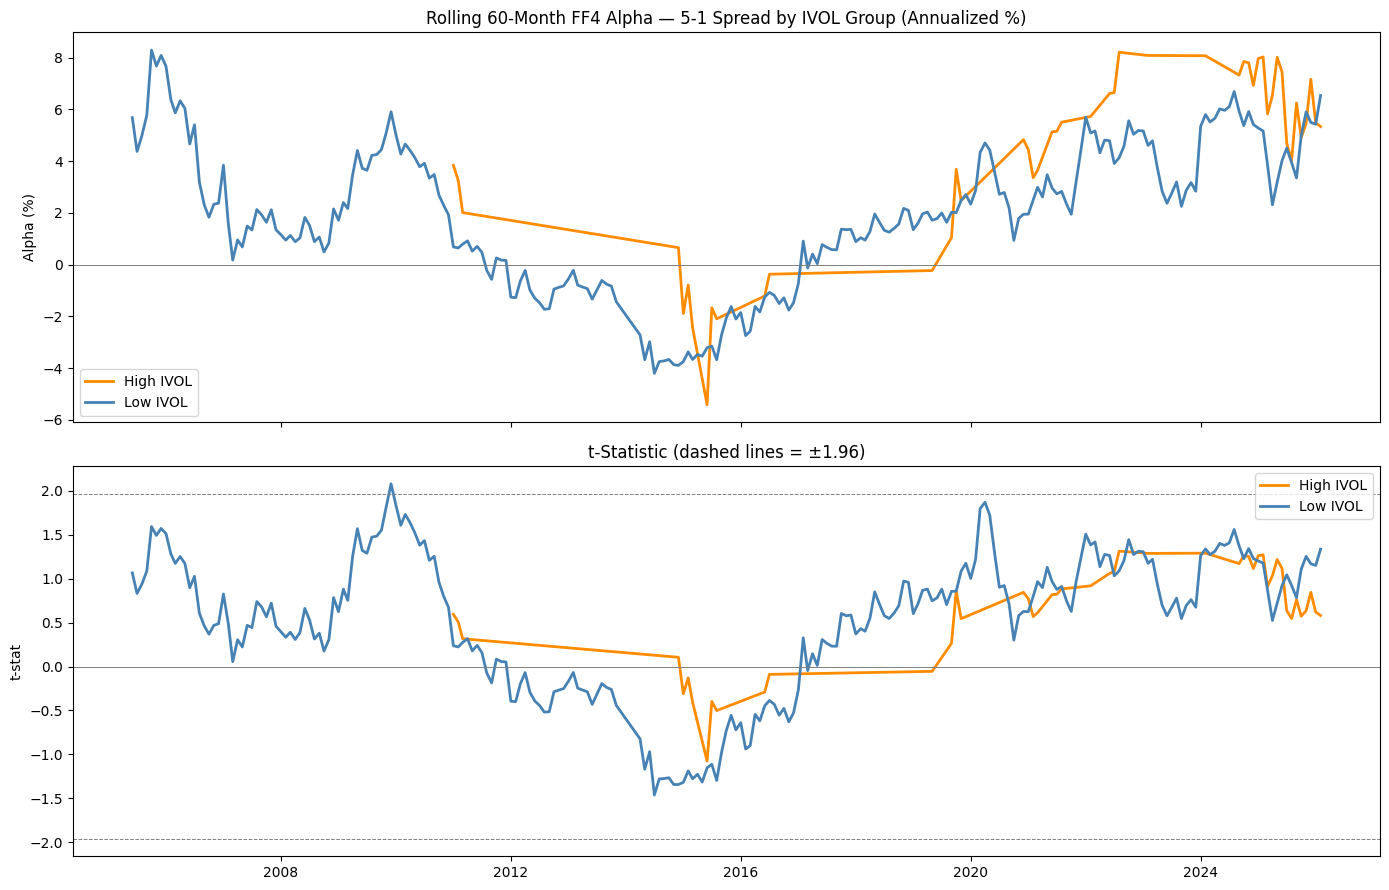

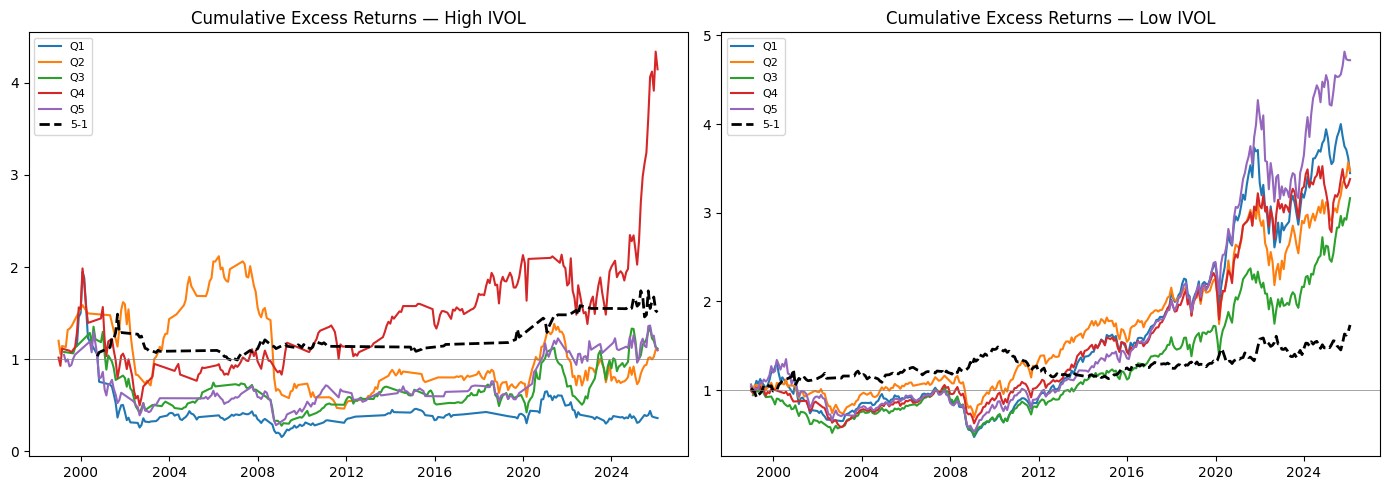

In [80]:
# Rolling alpha + cumulative returns by IVOL group
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
colors = {'High IVOL': 'darkorange', 'Low IVOL': 'steelblue'}
factor_label = 'FF4' if has_umd else 'FF3'

for grp, mat in rolling_ivol.items():
    roll_ivol, _ = rolling_alpha(mat['5-1'].dropna(), ff3)
    axes[0].plot(roll_ivol.index, roll_ivol['alpha'] * 100,
                 label=grp, color=colors[grp], linewidth=2)
    axes[1].plot(roll_ivol.index, roll_ivol['t_alpha'],
                 label=grp, color=colors[grp], linewidth=2)

axes[0].axhline(0, color='grey', linewidth=0.7)
axes[0].set_title(f'Rolling 60-Month {factor_label} Alpha — 5-1 Spread by IVOL Group (Annualized %)')
axes[0].set_ylabel('Alpha (%)')
axes[0].legend()

axes[1].axhline(0, color='grey', linewidth=0.7)
axes[1].axhline(1.96,  color='grey', linewidth=0.7, linestyle='--')
axes[1].axhline(-1.96, color='grey', linewidth=0.7, linestyle='--')
axes[1].set_title('t-Statistic (dashed lines = ±1.96)')
axes[1].set_ylabel('t-stat')
axes[1].legend()
plt.tight_layout()
plt.show()

# Cumulative returns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for (grp, mat), ax in zip(rolling_ivol.items(), axes):
    for col in [1, 2, 3, 4, 5]:
        cum = (1 + mat[col].dropna()).cumprod()
        ax.plot(cum.index, cum.values, label=f'Q{col}')
    spread = (1 + mat['5-1'].dropna()).cumprod()
    ax.plot(spread.index, spread.values, label='5-1', linestyle='--', color='black', linewidth=2)
    ax.axhline(1, color='grey', linewidth=0.5)
    ax.set_title(f'Cumulative Excess Returns — {grp}')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3c. Limits-to-Arbitrage Test — IVOL Double Sort

Split stocks into **High IVOL / Low IVOL** (above / below monthly median idiosyncratic volatility),
then assign CCH quintiles within each group.

**Mispricing prediction (Mashruwala et al. 2006):** CCH alpha should be concentrated in **High IVOL** stocks,
where idiosyncratic risk makes arbitrage costly and mispricing persists. If alpha is similar in both groups,
it suggests CCH captures a risk premium rather than a mispricing.

IVOL = trailing 12-month std of FF3 residuals (already computed in Section 4 setup).
⚠️ Coverage is limited (~30%) until FF factors are backfilled to 1997 — run `backfill_ff_factors.py --start 1997-01-01`.

In [81]:
# Per-ticker time-series factor regression → factor-adjusted (idiosyncratic) returns.
# adj_ret = excess_ret - factor_hat  (alpha stays in the residual)
def compute_factor_adjusted(df, factor_cols, out_col, min_obs=24):
    rows = []
    for ticker, grp in df.groupby('ticker'):
        valid = grp.dropna(subset=['ret_excess'] + factor_cols)
        if len(valid) < min_obs:
            continue
        y = valid['ret_excess'].values
        X = np.column_stack([np.ones(len(valid)), valid[factor_cols].values])
        try:
            beta, *_ = np.linalg.lstsq(X, y, rcond=None)
            factor_hat = X[:, 1:] @ beta[1:]
        except np.linalg.LinAlgError:
            continue
        tmp = valid[['ticker', 'date']].copy()
        tmp[out_col] = valid['ret_excess'].values - factor_hat
        rows.append(tmp)
    return pd.concat(rows, ignore_index=True)

# FF3-adjusted returns
adj_ff3 = compute_factor_adjusted(sample, ['mkt_rf', 'smb', 'hml'], 'adj_ret_ff3')
sample = sample.merge(adj_ff3, on=['ticker', 'date'], how='left')

# FF4-adjusted returns (available after re-running backfill_ff_factors.py to add UMD)
if 'umd' in sample.columns and sample['umd'].notna().any():
    adj_ff4 = compute_factor_adjusted(
        sample.dropna(subset=['umd']), ['mkt_rf', 'smb', 'hml', 'umd'], 'adj_ret_ff4'
    )
    sample = sample.merge(adj_ff4, on=['ticker', 'date'], how='left')
    print(f"adj_ret_ff4 coverage : {sample['adj_ret_ff4'].notna().sum():,}")
else:
    sample['adj_ret_ff4'] = np.nan
    print("UMD not available — re-run backfill_ff_factors.py to add FF4")

# Size
sample['ln_ME'] = np.log(sample['ME'].replace(0, np.nan))

# Momentum: cumulative return t-12 to t-2
sample['mom'] = sample.groupby('ticker')['ret'].transform(
    lambda x: x.shift(2).rolling(11).apply(lambda r: (1 + r).prod() - 1, raw=True)
)

# Idiosyncratic volatility: trailing 12-month std of FF3 residuals
sample['ivol'] = sample.groupby('ticker')['adj_ret_ff3'].transform(lambda x: x.rolling(12).std())

# Next-month factor-adjusted returns
sample['adj_ret_ff3_next'] = sample.groupby('ticker')['adj_ret_ff3'].shift(-1)
sample['adj_ret_ff4_next'] = sample.groupby('ticker')['adj_ret_ff4'].shift(-1)

print(f"adj_ret_ff3 coverage : {sample['adj_ret_ff3'].notna().sum():,}")
print(f"mom coverage         : {sample['mom'].notna().sum():,}")
print(f"ivol coverage        : {sample['ivol'].notna().sum():,}")

adj_ret_ff4 coverage : 1,322,524


KeyError: 'Column not found: adj_ret_ff3'

In [ ]:
def fama_macbeth(df, dep_var, signals):
    "Run Fama-MacBeth cross-sectional regressions. Returns coef and t-stat table."
    def cross_section(group):
        valid = group.dropna(subset=[dep_var] + signals)
        if len(valid) < 10:
            return None
        y = valid[dep_var]
        X = sm.add_constant(valid[signals])
        return sm.OLS(y, X).fit().params

    monthly_betas = []
    for date, group in df.groupby('date'):
        result = cross_section(group)
        if result is not None:
            monthly_betas.append(result)

    if not monthly_betas:
        print("No valid cross-sections found.")
        return pd.DataFrame()

    betas = pd.DataFrame(monthly_betas)
    n = len(betas)
    means = betas.mean()
    t_stats = means / (betas.std() / np.sqrt(n))
    return pd.DataFrame({'coef': means, 't-stat': t_stats}).round(4)

: 

: 

: 

In [ ]:
print('=== Model 1: CCH -> Raw Excess Return ===')
display(fama_macbeth(sample, 'ret_next_excess', ['CCH']))

print('\n=== Model 2: CCH -> FF3-Adjusted Return ===')
display(fama_macbeth(sample.dropna(subset=['adj_ret_ff3_next']), 'adj_ret_ff3_next', ['CCH']))

print('\n=== Model 3: CCH + Size + Momentum + iVol -> Raw Excess Return ===')
display(fama_macbeth(sample, 'ret_next_excess', ['CCH', 'ln_ME', 'mom', 'ivol']))

print('\n=== Model 4: CCH + Size + Momentum + iVol -> FF3-Adjusted Return ===')
display(fama_macbeth(
    sample.dropna(subset=['adj_ret_ff3_next']),
    'adj_ret_ff3_next',
    ['CCH', 'ln_ME', 'mom', 'ivol']
))

=== Model 1: CCH -> Raw Excess Return ===


,coef,t-stat
const,0.0040,1.1128
CCH,0.0157,4.0610



=== Model 2: CCH -> FF3-Adjusted Return ===


,coef,t-stat
const,-0.0030,-2.4313
CCH,0.0133,4.0274



=== Model 3: CCH + Size + Momentum + iVol -> Raw Excess Return ===


...


=== Model 4: CCH + Size + Momentum + iVol -> FF3-Adjusted Return ===


,coef,t-stat
const,0.0262,3.5549
CCH,0.0159,4.6842
ln_ME,-0.0011,-2.9439
mom,0.0062,4.3338
ivol,-0.0793,-7.3637


: 

: 

: 

## 5. VW Return Attribution — What Stocks Are Driving Returns?

In [ ]:
# Compute holding-level weights and contributions for VW portfolios
contrib = sample.dropna(subset=['CCH', 'ret_next_excess', 'ME', 'Q']).copy()
contrib['weight'] = contrib['ME'] / contrib.groupby(['date', 'Q'])['ME'].transform('sum')
contrib['contribution'] = contrib['weight'] * contrib['ret_next_excess']

# --- 1. Top contributors by total contribution per quintile ---
print("=== Top 15 stocks by total contribution (sum over all months) ===")
for q in [1, 5]:
    agg = (
        contrib[contrib['Q'] == q]
        .groupby('ticker')
        .agg(
            contribution=('contribution', 'sum'),
            avg_CCH=('CCH', 'mean'),
            median_ME_B=('ME', lambda x: x.median() / 1e9),
            n_months=('date', 'nunique'),
        )
        .sort_values('contribution', ascending=(q == 1))
        .head(15)
        .reset_index()
    )
    agg['contribution (%)'] = agg['contribution'] * 100
    agg = agg[['ticker', 'contribution (%)', 'avg_CCH', 'median_ME_B', 'n_months']]
    agg.columns = ['ticker', 'contribution (%)', 'avg CCH', 'median ME ($B)', 'months in Q']
    label = 'Q1 (Low CCH) — most negative' if q == 1 else 'Q5 (High CCH) — most positive'
    print(f"\n  {label}")
    display(agg)

=== Top 15 stocks by total contribution (sum over all months) ===

  Q1 (Low CCH) — most negative


,ticker,contribution (%),avg CCH,median ME ($B),months in Q
0,MSFT,-5.839269,-0.055098,494.40740,57
1,LU1,-4.627350,-0.048757,13.60300,23
2,META,-4.051397,-0.059830,552.05810,43
3,JAVA1,-3.753892,-0.054212,17.24955,36
4,JNPR,-2.954144,-0.068725,9.88360,70
5,PFE,-2.874874,-0.074395,195.03690,55
6,BRCM,-2.817794,-0.098154,18.60180,37
7,KO,-2.787755,-0.042442,175.07705,46
8,EBAY,-2.499989,-0.066681,33.57005,104
9,BMY,-2.489436,-0.081224,58.28220,59



  Q5 (High CCH) — most positive


,ticker,contribution (%),avg CCH,median ME ($B),months in Q
0,NVDA,22.284894,0.036619,49.69580,55
1,META,11.667795,0.032881,348.61020,44
2,AMZN,9.831918,0.053333,31.47510,85
3,AAPL,6.976697,0.036207,662.90690,76
4,TSLA,5.070085,0.066324,54.93945,44
5,UNH,3.946748,0.035424,72.88430,66
6,GOOGL,3.907822,0.042049,122.73520,15
7,V,3.810456,0.046396,397.87910,41
8,JAVA1,3.432409,0.037953,16.19440,33
9,LLY,3.302717,0.035449,85.82380,83


: 

: 

: 

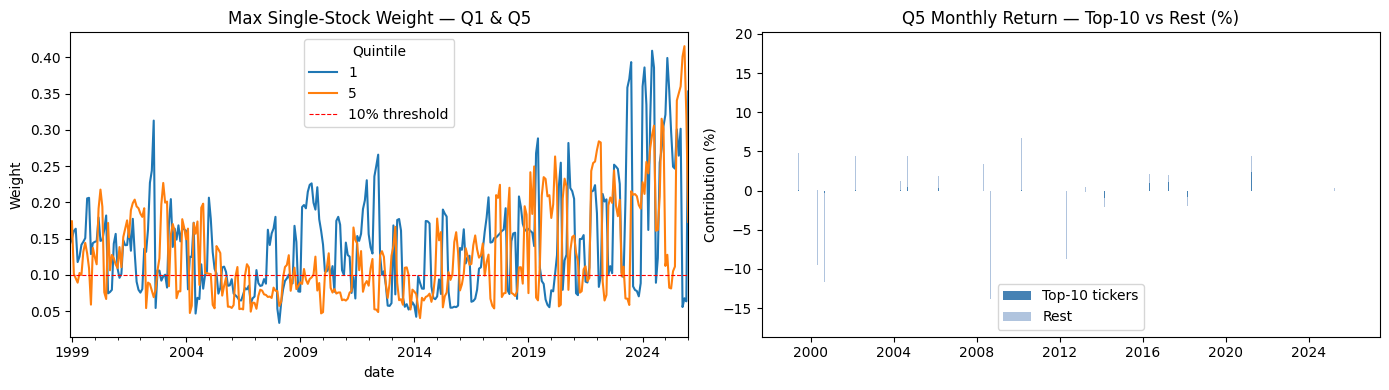


Top-10 tickers explain 35.9% of Q5 total VW contribution


: 

: 

: 

In [ ]:
# --- 2. Concentration check: max single-stock weight per month per quintile ---
max_weight = contrib.groupby(['date', 'Q']).apply(
    lambda g: (g['ME'] / g['ME'].sum()).max()
).unstack('Q')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

max_weight[[1, 5]].plot(ax=axes[0], title='Max Single-Stock Weight — Q1 & Q5')
axes[0].set_ylabel('Weight')
axes[0].axhline(0.1, color='red', linewidth=0.8, linestyle='--', label='10% threshold')
axes[0].legend(title='Quintile')

# --- 3. Monthly contribution of top-10 tickers vs rest for Q5 ---
top10_q5 = (
    contrib[contrib['Q'] == 5]
    .groupby('ticker')['contribution']
    .sum()
    .nlargest(10)
    .index
)
q5 = contrib[contrib['Q'] == 5].copy()
q5['group'] = q5['ticker'].apply(lambda t: t if t in top10_q5 else '_rest')
monthly = q5.groupby(['date', 'group'])['contribution'].sum().unstack('group').fillna(0)
monthly_top10 = monthly[list(top10_q5)].sum(axis=1)
monthly_rest  = monthly['_rest']

axes[1].bar(monthly.index, monthly_top10 * 100, label='Top-10 tickers', color='steelblue')
axes[1].bar(monthly.index, monthly_rest * 100, bottom=monthly_top10 * 100, label='Rest', color='lightsteelblue')
axes[1].set_title('Q5 Monthly Return — Top-10 vs Rest (%)')
axes[1].set_ylabel('Contribution (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Print how much of Q5 total return the top-10 explains
total_q5 = contrib[contrib['Q'] == 5]['contribution'].sum()
top10_total = contrib[(contrib['Q'] == 5) & (contrib['ticker'].isin(top10_q5))]['contribution'].sum()
print(f"\nTop-10 tickers explain {top10_total/total_q5*100:.1f}% of Q5 total VW contribution")

## 5b. VW Return Attribution — Low ME Stocks

In [ ]:
# Attribution for Low ME double-sorted portfolios
contrib_lme = sample_port[sample_port['size_group'] == 'Low ME'].copy()
contrib_lme['weight'] = contrib_lme['ME'] / contrib_lme.groupby(['date', 'Q_me'])['ME'].transform('sum')
contrib_lme['contribution'] = contrib_lme['weight'] * contrib_lme['ret_next_excess']

# --- 1. Top contributors per quintile ---
print("=== Low ME — Top 15 stocks by total contribution ===")
for q in [1, 5]:
    agg = (
        contrib_lme[contrib_lme['Q_me'] == q]
        .groupby('ticker')
        .agg(
            contribution=('contribution', 'sum'),
            avg_CCH=('CCH', 'mean'),
            median_ME_M=('ME', lambda x: x.median() / 1e6),  # millions for small caps
            n_months=('date', 'nunique'),
        )
        .sort_values('contribution', ascending=(q == 1))
        .head(15)
        .reset_index()
    )
    agg['contribution (%)'] = agg['contribution'] * 100
    agg = agg[['ticker', 'contribution (%)', 'avg_CCH', 'median_ME_M', 'n_months']]
    agg.columns = ['ticker', 'contribution (%)', 'avg CCH', 'median ME ($M)', 'months in Q']
    label = 'Q1 (Low CCH) — most negative' if q == 1 else 'Q5 (High CCH) — most positive'
    print(f"\n  {label}")
    display(agg)

=== Low ME — Top 15 stocks by total contribution ===

  Q1 (Low CCH) — most negative


,ticker,contribution (%),avg CCH,median ME ($M),months in Q
0,ASXC,-1.848767,-0.111366,71.20,113
1,ABEO,-1.608297,-0.084824,39.75,118
2,APPHQ,-1.383453,-0.116566,305.00,19
3,KRRO,-1.339215,-0.051470,275.35,34
4,WAVXQ,-1.272625,-0.097260,65.95,66
5,WWR,-1.246968,-0.078065,40.40,119
6,VSTM,-1.231240,-0.162456,255.90,19
7,GGLR,-1.230749,-0.070419,115.15,58
8,TSHA,-1.199046,-0.088959,150.80,25
9,NKTX,-1.169121,-0.063200,202.50,19



  Q5 (High CCH) — most positive


,ticker,contribution (%),avg CCH,median ME ($M),months in Q
0,OCUL,2.985733,0.047047,252.40,21
1,BCRX,2.941195,0.092952,195.00,77
2,BBBY,2.202045,0.084096,291.30,19
3,ARRY1,2.076526,0.080410,157.10,27
4,ENTG,2.052209,0.088611,126.95,4
5,BFXXQ,1.932382,0.061892,167.20,71
6,TRML,1.822755,0.025880,430.30,16
7,OMER,1.814840,0.094450,317.25,34
8,TEN1,1.802329,0.213290,97.30,6
9,VXRT,1.785945,0.090508,82.90,45


: 

: 

: 

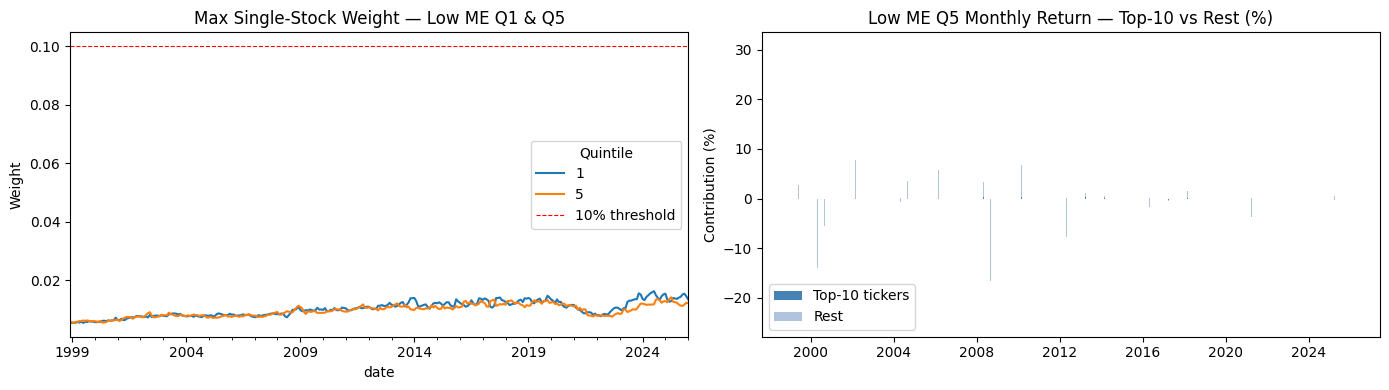


Top-10 Low ME tickers explain 11.9% of Low ME Q5 total VW contribution


: 

: 

: 

In [ ]:
# --- 2. Concentration check + Q5 stacked bar for Low ME ---
max_weight_lme = contrib_lme.groupby(['date', 'Q_me']).apply(
    lambda g: (g['ME'] / g['ME'].sum()).max()
).unstack('Q_me')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

max_weight_lme[[1, 5]].plot(ax=axes[0], title='Max Single-Stock Weight — Low ME Q1 & Q5')
axes[0].set_ylabel('Weight')
axes[0].axhline(0.1, color='red', linewidth=0.8, linestyle='--', label='10% threshold')
axes[0].legend(title='Quintile')

top10_lme_q5 = (
    contrib_lme[contrib_lme['Q_me'] == 5]
    .groupby('ticker')['contribution']
    .sum()
    .nlargest(10)
    .index
)
q5_lme = contrib_lme[contrib_lme['Q_me'] == 5].copy()
q5_lme['group'] = q5_lme['ticker'].apply(lambda t: t if t in top10_lme_q5 else '_rest')
monthly_lme = q5_lme.groupby(['date', 'group'])['contribution'].sum().unstack('group').fillna(0)
monthly_lme_top10 = monthly_lme[list(top10_lme_q5)].sum(axis=1)
monthly_lme_rest  = monthly_lme['_rest']

axes[1].bar(monthly_lme.index, monthly_lme_top10 * 100, label='Top-10 tickers', color='steelblue')
axes[1].bar(monthly_lme.index, monthly_lme_rest * 100, bottom=monthly_lme_top10 * 100, label='Rest', color='lightsteelblue')
axes[1].set_title('Low ME Q5 Monthly Return — Top-10 vs Rest (%)')
axes[1].set_ylabel('Contribution (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

total_lme_q5  = contrib_lme[contrib_lme['Q_me'] == 5]['contribution'].sum()
top10_lme_tot = contrib_lme[(contrib_lme['Q_me'] == 5) & (contrib_lme['ticker'].isin(top10_lme_q5))]['contribution'].sum()
print(f"\nTop-10 Low ME tickers explain {top10_lme_tot/total_lme_q5*100:.1f}% of Low ME Q5 total VW contribution")

## 6. Most Recent CCH Signal Rankings

In [ ]:
# Most recent month with CCH signal — use df directly (not sample) to get the true latest
# sample requires ret_next, which means the last month in df is always missing from sample
latest_date = df[df['CCH'].notna()]['date'].max()
print(f"Most recent CCH date: {latest_date.date()}  (df goes to {df['date'].max().date()})\n")

latest = df[df['date'] == latest_date].dropna(subset=['CCH']).copy()
latest['rank'] = latest['CCH'].rank(ascending=False, method='first').astype(int)
latest['ME_B'] = latest['ME'] / 1e9

display_cols = ['rank', 'ticker', 'CCH', 'ME_B']

# --- Full universe: top and bottom 20 ---
print(f"=== Full Universe ({latest['ticker'].nunique()} tickers) ===")

print("\n  Top 20 (highest CCH — most liquid build-up):")
display(
    latest.nsmallest(20, 'rank')[display_cols]
    .rename(columns={'ME_B': 'ME ($B)', 'rank': 'CCH rank'})
    .reset_index(drop=True)
)

print("\n  Bottom 20 (lowest CCH — most liquid draw-down):")
display(
    latest.nlargest(20, 'rank')[display_cols]
    .rename(columns={'ME_B': 'ME ($B)', 'rank': 'CCH rank'})
    .reset_index(drop=True)
)

# --- Low ME subset ---
me_median = latest['ME'].median()
latest_lme = latest[latest['ME'] < me_median].copy()
latest_lme['rank_lme'] = latest_lme['CCH'].rank(ascending=False, method='first').astype(int)

display_cols_lme = ['rank_lme', 'ticker', 'CCH', 'ME_B']
print(f"\n=== Low ME Universe ({latest_lme['ticker'].nunique()} tickers, ME < ${me_median/1e9:.2f}B) ===")

print("\n  Top 20 (highest CCH):")
display(
    latest_lme.nsmallest(20, 'rank_lme')[display_cols_lme]
    .rename(columns={'ME_B': 'ME ($B)', 'rank_lme': 'CCH rank (Low ME)'})
    .reset_index(drop=True)
)

print("\n  Bottom 20 (lowest CCH):")
display(
    latest_lme.nlargest(20, 'rank_lme')[display_cols_lme]
    .rename(columns={'ME_B': 'ME ($B)', 'rank_lme': 'CCH rank (Low ME)'})
    .reset_index(drop=True)
)

Most recent CCH date: 2026-04-30  (df goes to 2026-04-30)

=== Full Universe (3547 tickers) ===

  Top 20 (highest CCH — most liquid build-up):


,CCH rank,ticker,CCH,ME ($B)
0,1,GLND,0.998123,0.1337
1,2,CABR,0.985496,0.0154
2,3,FVN,0.981389,0.0818
3,4,AMCI,0.979255,0.1604
4,5,AQB,0.936743,0.0050
5,6,BIII,0.822651,0.2270
6,7,MOVE,0.806428,0.0204
7,8,PHGE,0.625375,0.0023
8,9,SHAZ,0.577750,0.5871
9,10,XHLD,0.577435,0.0064



  Bottom 20 (lowest CCH — most liquid draw-down):


,CCH rank,ticker,CCH,ME ($B)
0,3547,ALIS,-0.990360,0.0846
1,3546,CNTN,-0.966510,0.1989
2,3545,GIW,-0.945259,0.3647
3,3544,DFNS,-0.920272,0.0261
4,3543,AIIA,-0.909893,0.1939
5,3542,TRAD.U,-0.909487,0.1431
6,3541,SHPH,-0.873806,0.0055
7,3540,HAVA,-0.822139,0.2078
8,3539,KRSP,-0.785162,0.4734
9,3538,VWAV,-0.782037,0.1185



=== Low ME Universe (1773 tickers, ME < $0.80B) ===

  Top 20 (highest CCH):


...


  Bottom 20 (lowest CCH):


,CCH rank (Low ME),ticker,CCH,ME ($B)
0,1773,ALIS,-0.990360,0.0846
1,1772,CNTN,-0.966510,0.1989
2,1771,GIW,-0.945259,0.3647
3,1770,DFNS,-0.920272,0.0261
4,1769,AIIA,-0.909893,0.1939
5,1768,TRAD.U,-0.909487,0.1431
6,1767,SHPH,-0.873806,0.0055
7,1766,HAVA,-0.822139,0.2078
8,1765,KRSP,-0.785162,0.4734
9,1764,VWAV,-0.782037,0.1185


: 

: 

: 

## 7. Per-Ticker Signal Visualizer

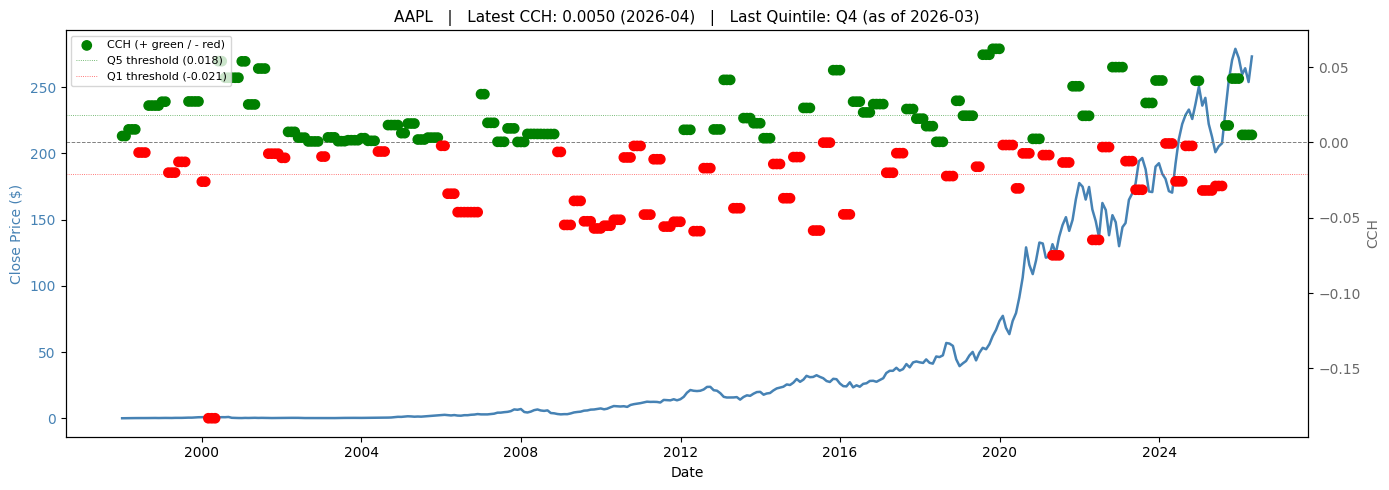

: 

: 

: 

In [ ]:
def plot_ticker_signal(ticker: str):
    t = df[df['ticker'] == ticker].sort_values('date').copy()
    if t.empty:
        print(f"Ticker '{ticker}' not found.")
        return

    # Attach quintile from sample (only months where ret_next is known)
    q_lookup = sample[sample['ticker'] == ticker][['date', 'Q']].drop_duplicates()
    t = t.merge(q_lookup, on='date', how='left')

    has_signal = t['CCH'].notna().any()
    fig, ax1 = plt.subplots(figsize=(14, 5))

    # Price — blue line (full history)
    ax1.plot(t['date'], t['close'], color='steelblue', linewidth=1.8)
    ax1.set_ylabel('Close Price ($)', color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue')
    ax1.set_xlabel('Date')

    if has_signal:
        sig = t.dropna(subset=['CCH'])
        ax2 = ax1.twinx()

        dot_colors = sig['CCH'].apply(lambda v: 'green' if v > 0 else 'red')
        ax2.scatter(sig['date'], sig['CCH'], c=dot_colors, s=45, zorder=5, label='CCH (+ green / - red)')
        ax2.axhline(0, color='grey', linewidth=0.7, linestyle='--')
        ax2.set_ylabel('CCH', color='dimgray')
        ax2.tick_params(axis='y', labelcolor='dimgray')

        q20 = sample['CCH'].quantile(0.20)
        q80 = sample['CCH'].quantile(0.80)
        ax2.axhline(q80, color='green', linewidth=0.6, linestyle=':', alpha=0.7, label=f'Q5 threshold ({q80:.3f})')
        ax2.axhline(q20, color='red',   linewidth=0.6, linestyle=':', alpha=0.7, label=f'Q1 threshold ({q20:.3f})')
        ax2.legend(loc='upper left', fontsize=8)

    # Title: latest CCH date + last ranked quintile (sample lags df by 1 month)
    latest_cch_row  = t.dropna(subset=['CCH']).tail(1)
    last_ranked_row = t.dropna(subset=['CCH', 'Q']).tail(1)

    if not latest_cch_row.empty:
        cch_val  = latest_cch_row['CCH'].iloc[0]
        cch_date = latest_cch_row['date'].iloc[0].strftime('%Y-%m')
        if not last_ranked_row.empty:
            q_val  = int(last_ranked_row['Q'].iloc[0])
            q_date = last_ranked_row['date'].iloc[0].strftime('%Y-%m')
            q_str  = f'Q{q_val} (as of {q_date})'
        else:
            q_str = 'not yet ranked'
        ax1.set_title(
            f'{ticker}   |   Latest CCH: {cch_val:.4f} ({cch_date})   |   Last Quintile: {q_str}',
            fontsize=11
        )
    else:
        ax1.set_title(f'{ticker}   |   No CCH signal available', fontsize=12)

    fig.tight_layout()
    plt.show()


# --- Change ticker here ---
plot_ticker_signal('AAPL')

In [ ]:
df[df['ticker'] == 'INFQ']

,ticker,close,date,ret,ME,CCH,mkt_rf,smb,hml,rf,umd,ret_excess,ret_next,ret_next_excess
831747,INFQ,10.335,2025-05-31,NaN,3.907000e+08,NaN,0.0606,0.0070,-0.0288,0.0038,0.0221,NaN,-0.003290,-0.006690
831748,INFQ,10.301,2025-06-30,-0.003290,5.362000e+08,NaN,0.0486,0.0083,-0.0161,0.0034,-0.0264,-0.006690,-0.015144,-0.018544
831749,INFQ,10.145,2025-07-31,-0.015144,5.280000e+08,NaN,0.0198,0.0027,-0.0127,0.0034,-0.0097,-0.018544,-0.002464,-0.006264
831750,INFQ,10.120,2025-08-31,-0.002464,5.267000e+08,NaN,0.0184,0.0387,0.0442,0.0038,-0.0354,-0.006264,0.270751,0.267451
831751,INFQ,12.860,2025-09-30,0.270751,6.694000e+08,NaN,0.0339,-0.0185,-0.0105,0.0033,0.0463,0.267451,0.497667,0.493967
831752,INFQ,19.260,2025-10-31,0.497667,1.002500e+09,NaN,0.0196,-0.0055,-0.0310,0.0037,0.0027,0.493967,-0.234164,-0.237164
831753,INFQ,14.750,2025-11-30,-0.234164,7.677000e+08,-0.000278,-0.0013,0.0038,0.0376,0.0030,-0.0180,-0.237164,0.057627,0.054227
831754,INFQ,15.600,2025-12-31,0.057627,8.120000e+08,-0.000278,-0.0036,-0.0106,0.0242,0.0034,-0.0241,0.054227,-0.134615,-0.137615
831755,INFQ,13.500,2026-01-31,-0.134615,7.027000e+08,-0.000278,0.0102,0.0220,0.0372,0.0030,0.0496,-0.137615,-0.137778,-0.140578
831756,INFQ,11.640,2026-02-28,-0.137778,2.519700e+09,0.795928,-0.0117,0.0014,0.0283,0.0028,0.0133,-0.140578,-0.157216,NaN


: 

: 

: 

In [ ]:
sf1_raw = s3.read_sharadar_sf1()
sf1_raw[sf1_raw['ticker'] == 'INFQ'][['datekey', 'assetsc', 'assets']].sort_values('datekey')

,datekey,assetsc,assets
310524,2025-05-09,NaN,157937.0
310525,2025-06-13,NaN,170882.0
310526,2025-08-13,1633193.0,418059568.0
310527,2025-11-12,1528696.0,421268662.0
310528,2026-02-17,95603000.0,119570000.0
310529,2026-03-31,74624000.0,115313000.0


: 

: 

: 

: 

: 

: 